# Import

In [ ]:
from matplotlib import pyplot as plt
from march.module import DMC
from march.ops.grid import create_voxel_grid

import torch
import tqdm
import numpy as np
import kaolin as kal
import plotly.graph_objects as go
import render
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
iter = 1000
batch = 8
train_res = [2048, 2048]
learning_rate = 0.01
voxel_grid_res = 16
device = 'cuda'

# GT Mesh

In [3]:
mesh = o3d.geometry.TriangleMesh.create_sphere(radius=1.0, resolution=20)

print("# vertices:", len(mesh.vertices))
print("# triangles:", len(mesh.triangles))

print(type(mesh))

# vertices: 762
# triangles: 1520
<class 'open3d.cuda.pybind.geometry.TriangleMesh'>


In [4]:
vertices = np.asarray(mesh.vertices).astype(np.float32)
triangles = np.asarray(mesh.triangles).astype(np.int64)

print(f"vertices: {vertices.shape}, triangles: {triangles.shape}")
print(f"vertices: {vertices.dtype}, triangles: {triangles.dtype}")
print(f"vertices min: {vertices.min()}, \nvertices max: {vertices.max()}")

vertices: (762, 3), triangles: (1520, 3)
vertices: float32, triangles: int64
vertices min: -1.0, 
vertices max: 1.0


In [5]:
vertices = torch.from_numpy(vertices).float()
triangles = torch.from_numpy(triangles).long()

vmin, vmax = vertices.min(dim=0)[0], vertices.max(dim=0)[0]
scale = 1.8 / torch.max(vmax - vmin).item()

vertices = vertices - (vmax + vmin) / 2
vertices = vertices * scale

print(f"vertices min: {vertices.min()}, \nvertices max: {vertices.max()}")

vertices min: -0.8999999761581421, 
vertices max: 0.8999999761581421


In [6]:
fig = go.Figure()

fig.add_trace(go.Mesh3d(
    x=vertices[:, 0],
    y=vertices[:, 1],
    z=vertices[:, 2],
    i=triangles[:, 0],
    j=triangles[:, 1],
    k=triangles[:, 2],
    opacity=0.1,
    color='lightblue',
    showlegend=False
))

# Add wireframe edges
edges_x = []
edges_y = []
edges_z = []
for i, j, k in triangles:
    # Edge 1: vertex i to j
    edges_x.extend([vertices[i, 0], vertices[j, 0], None])
    edges_y.extend([vertices[i, 1], vertices[j, 1], None])
    edges_z.extend([vertices[i, 2], vertices[j, 2], None])
    # Edge 2: vertex j to k
    edges_x.extend([vertices[j, 0], vertices[k, 0], None])
    edges_y.extend([vertices[j, 1], vertices[k, 1], None])
    edges_z.extend([vertices[j, 2], vertices[k, 2], None])
    # Edge 3: vertex k to i
    edges_x.extend([vertices[k, 0], vertices[i, 0], None])
    edges_y.extend([vertices[k, 1], vertices[i, 1], None])
    edges_z.extend([vertices[k, 2], vertices[i, 2], None])

fig.add_trace(go.Scatter3d(
    x=edges_x,
    y=edges_y,
    z=edges_z,
    mode='lines',
    line=dict(color='darkblue', width=2),
    name='Mesh Edges',
    showlegend=True
))

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    title='Grid Points and Marching Cubes Mesh (Wireframe)',
    width=800,
    height=800
)

fig.show()

In [7]:
vertices = vertices.to(device)
triangles = triangles.to(device)

gt_mesh = kal.rep.SurfaceMesh(vertices=vertices, faces=triangles)

# Voxel Grid

In [8]:
bound_scale = 1.2
bound_max = (vertices.max() * bound_scale).item()
bound_min = (vertices.min() * bound_scale).item()

bounds = [[bound_min, bound_max], [bound_min, bound_max], [bound_min, bound_max]]

print(f"bounds: {bounds}")

bounds: [[-1.0800000429153442, 1.0800000429153442], [-1.0800000429153442, 1.0800000429153442], [-1.0800000429153442, 1.0800000429153442]]


In [9]:
grid_vertices, cubes = create_voxel_grid(res_x=voxel_grid_res, res_y=voxel_grid_res, res_z=voxel_grid_res, bounds=bounds, device=device)

print(f"grid_vertices: {grid_vertices.shape}, cubes: {cubes.shape}")
print(f"grid_vertices: {grid_vertices.dtype}, cubes: {cubes.dtype}")
print(f"grid_vertices min: {grid_vertices.min()}, grid_vertices max: {grid_vertices.max()}")

grid_vertices: (4913, 3), cubes: (4096, 8)
grid_vertices: float32, cubes: int32
grid_vertices min: -1.0800000429153442, grid_vertices max: 1.0800000429153442


In [10]:
grid_vertices = torch.from_numpy(grid_vertices).float().to(device)
cubes = torch.from_numpy(cubes).to(device)

print(f"grid_vertices: {grid_vertices.shape}, cubes: {cubes.shape}")

grid_vertices: torch.Size([4913, 3]), cubes: torch.Size([4096, 8])


In [11]:
sdf = torch.rand_like(grid_vertices[:,0]) - 0.1
sdf = torch.nn.Parameter(sdf.clone().detach(), requires_grad=True)

print(f"sdf: {sdf.shape}, {sdf.dtype}")
print(f"sdf min: {sdf.min()}, sdf max: {sdf.max()}")
print(f"sdf requires_grad: {sdf.requires_grad}")

sdf: torch.Size([4913]), torch.float32
sdf min: -0.09996261447668076, sdf max: 0.8998392820358276
sdf requires_grad: True


# Marching Cube Module

In [12]:
mc = DMC()
print(mc)

DMC()


In [13]:
with torch.no_grad():
    vertices, faces = mc(grid_vertices, cubes, sdf, 0.0)

print(f"vertices: {vertices.shape}, faces: {faces.shape}")

vertices: torch.Size([2428, 3]), faces: torch.Size([3734, 3])


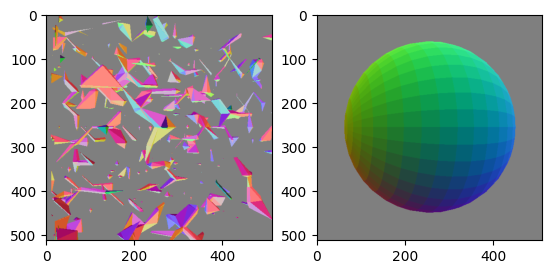

In [14]:
init_mesh = kal.rep.SurfaceMesh(vertices=vertices, faces=faces)

camera = render.get_rotate_camera(0)
f, ax = plt.subplots(1, 2)
output = render.render_mesh(init_mesh, camera, [512, 512], return_types=['normals'])
ax[0].imshow(((output['normals'][0] + 1) / 2.).cpu().detach())
output = render.render_mesh(gt_mesh, camera, [512, 512], return_types=['normals'])
ax[1].imshow(((output['normals'][0] + 1) / 2.).cpu().detach())
plt.show()

# Optimization

In [15]:
def lr_schedule(iter):
    return max(0.0, 10 ** (-(iter) * 0.0002)) # Exponential falloff from [1.0, 0.1] over 5k epochs.    
optimizer = torch.optim.Adam([sdf], lr=learning_rate)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda x: lr_schedule(x)) 

In [17]:
intermediate_results = [init_mesh]
for it in tqdm.tqdm(range(iter)): 
    optimizer.zero_grad()
    # sample random camera poses
    cameras = render.get_random_camera_batch(batch, iter_res=train_res, device=device)
    
    # render gt mesh at sampled views
    target = render.render_mesh(gt_mesh, cameras, train_res, return_types = ["mask", "depth", "normals"])

    # extract and render FlexiCubes mesh
    vertices, faces = mc(
        grid_vertices=grid_vertices, 
        cubes=cubes, 
        values=sdf, 
        iso=0.0
    )
    
    extracted_mesh = kal.rep.SurfaceMesh(vertices=vertices, faces=faces)
    buffers = render.render_mesh(extracted_mesh, cameras, train_res, return_types = ["mask", "depth", "normals"])

    # reconstruction loss
    mask_loss = (buffers['mask'] - target['mask']).abs().mean() # mask loss
    depth_loss = (((((buffers['depth'] - (target['depth'])) * target['mask'])**2).sum(-1)+1e-8)).sqrt().mean() * 10 # depth loss
    # normals_loss = (((((buffers['normals'] - (target['normals'])) * target['mask'])**2).sum(-1)+1e-8)).sqrt().mean() * 10 # normals loss

    # total_loss = mask_loss + depth_loss + normals_loss
    total_loss = mask_loss + depth_loss
    total_loss.backward()
    optimizer.step()
    scheduler.step()
    
    if (it + 1) % 100 == 0: # save intermediate results every 100 iters
        # print(f"Iter {it+1}/{iter}, Mask Loss: {mask_loss.item():.4f}, Depth Loss: {depth_loss.item():.4f}, Normals Loss: {normals_loss.item():.4f}")
        print(f"Iter {it+1}/{iter}, Mask Loss: {mask_loss.item():.4f}, Depth Loss: {depth_loss.item():.4f}")

 10%|█         | 104/1000 [00:04<00:39, 22.69it/s]

Iter 100/1000, Mask Loss: 0.0066, Depth Loss: 0.1187


 20%|██        | 203/1000 [00:08<00:35, 22.61it/s]

Iter 200/1000, Mask Loss: 0.0013, Depth Loss: 0.0229


 30%|███       | 302/1000 [00:13<00:30, 22.60it/s]

...

Iter 800/1000, Mask Loss: 0.0011, Depth Loss: 0.0220


 90%|█████████ | 902/1000 [00:39<00:04, 22.65it/s]

Iter 900/1000, Mask Loss: 0.0011, Depth Loss: 0.0225


100%|██████████| 1000/1000 [00:44<00:00, 22.61it/s]

Iter 1000/1000, Mask Loss: 0.0012, Depth Loss: 0.0231


In [18]:
with torch.no_grad():
    vertices, faces = mc(
        grid_vertices=grid_vertices, 
        cubes=cubes, 
        values=sdf, 
        iso=0.0
    )
    
final_mesh = kal.rep.SurfaceMesh(vertices=vertices, faces=faces)

In [19]:
print(f"Final vertices: {vertices.shape}, Final faces: {faces.shape}")

Final vertices: torch.Size([1704, 3]), Final faces: torch.Size([3204, 3])


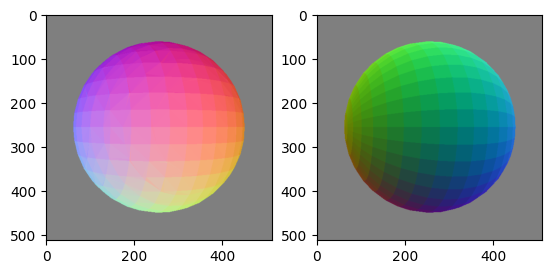

In [20]:
camera = render.get_rotate_camera(0)
f, ax = plt.subplots(1, 2)
output = render.render_mesh(final_mesh, camera, [512, 512], return_types=['normals'])
ax[0].imshow(((output['normals'][0] + 1) / 2.).cpu().detach())
output = render.render_mesh(gt_mesh, camera, [512, 512], return_types=['normals'])
ax[1].imshow(((output['normals'][0] + 1) / 2.).cpu().detach())
plt.show()

In [21]:
vertices = vertices.cpu()
triangles = faces.cpu()

grids_numpy = grid_vertices.cpu().numpy()

# Create color array: red if value > iso, blue otherwise
colors = ['red' if v > 0.0 else 'blue' for v in sdf.detach().cpu().numpy()]

fig = go.Figure()

fig.add_trace(go.Mesh3d(
    x=vertices[:, 0],
    y=vertices[:, 1],
    z=vertices[:, 2],
    i=triangles[:, 0],
    j=triangles[:, 1],
    k=triangles[:, 2],
    opacity=0.1,
    color='lightblue',
    showlegend=False
))

# Add grid points as scatter plot
fig.add_trace(go.Scatter3d(
    x=grids_numpy[:, 0],
    y=grids_numpy[:, 1],
    z=grids_numpy[:, 2],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    name='Grid Points'
))

# Add wireframe edges
edges_x = []
edges_y = []
edges_z = []
for i, j, k in triangles:
    # Edge 1: vertex i to j
    edges_x.extend([vertices[i, 0], vertices[j, 0], None])
    edges_y.extend([vertices[i, 1], vertices[j, 1], None])
    edges_z.extend([vertices[i, 2], vertices[j, 2], None])
    # Edge 2: vertex j to k
    edges_x.extend([vertices[j, 0], vertices[k, 0], None])
    edges_y.extend([vertices[j, 1], vertices[k, 1], None])
    edges_z.extend([vertices[j, 2], vertices[k, 2], None])
    # Edge 3: vertex k to i
    edges_x.extend([vertices[k, 0], vertices[i, 0], None])
    edges_y.extend([vertices[k, 1], vertices[i, 1], None])
    edges_z.extend([vertices[k, 2], vertices[i, 2], None])

fig.add_trace(go.Scatter3d(
    x=edges_x,
    y=edges_y,
    z=edges_z,
    mode='lines',
    line=dict(color='darkblue', width=2),
    name='Mesh Edges',
    showlegend=True
))

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    title='Grid Points and Marching Cubes Mesh (Wireframe)',
    width=800,
    height=800
)

fig.show()